In [1]:
# basic sanity checks

import pandas as pd
import numpy as np

# File path (provided in this environment)
DATA_PATH = "online_retail.csv"

# Read the dataset
df = pd.read_csv(DATA_PATH)

# Basic sanity checks
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape (rows, columns): (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:


# 1) Parse InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# 2) Convert CustomerID to nullable integer (keeps missing values as <NA>)
df["CustomerID"] = df["CustomerID"].round().astype("Int64")

# 3) Create transaction quality flags
df["IsCancellation"] = df["InvoiceNo"].astype(str).str.startswith(("C", "c"))
df["IsReturnLike"] = (df["Quantity"] <= 0) | (df["UnitPrice"] <= 0)

# Quick verification
print("InvoiceDate parsing: null timestamps =", df["InvoiceDate"].isna().sum())
print("CustomerID missing =", df["CustomerID"].isna().sum())
print("Cancellations (InvoiceNo starts with C) =", df["IsCancellation"].sum())
print("Return-like records (Qty<=0 or UnitPrice<=0) =", df["IsReturnLike"].sum())

# Show a small sample of flagged rows (if any exist)
display(df.loc[df["IsCancellation"] | df["IsReturnLike"], 
               ["InvoiceNo","Quantity","UnitPrice","CustomerID","InvoiceDate","IsCancellation","IsReturnLike"]].head(10))

InvoiceDate parsing: null timestamps = 0
CustomerID missing = 135080
Cancellations (InvoiceNo starts with C) = 9288
Return-like records (Qty<=0 or UnitPrice<=0) = 11805


,InvoiceNo,Quantity,UnitPrice,CustomerID,InvoiceDate,IsCancellation,IsReturnLike
141,C536379,-1,27.50,14527,2010-12-01 09:41:00,True,True
154,C536383,-1,4.65,15311,2010-12-01 09:49:00,True,True
235,C536391,-12,1.65,17548,2010-12-01 10:24:00,True,True
236,C536391,-24,0.29,17548,2010-12-01 10:24:00,True,True
237,C536391,-24,0.29,17548,2010-12-01 10:24:00,True,True
238,C536391,-24,0.29,17548,2010-12-01 10:24:00,True,True
239,C536391,-12,3.45,17548,2010-12-01 10:24:00,True,True
240,C536391,-12,1.65,17548,2010-12-01 10:24:00,True,True
241,C536391,-24,1.65,17548,2010-12-01 10:24:00,True,True
622,536414,56,0.00,<NA>,2010-12-01 11:52:00,False,True


In [3]:

# 1) Clean sales dataset (used for RFM, cohorts, churn modeling)
df_sales = df.loc[
    (~df["IsCancellation"]) &
    (~df["IsReturnLike"]) &
    (df["CustomerID"].notna())
].copy()

df_sales["Revenue"] = df_sales["Quantity"] * df_sales["UnitPrice"]

# 2) Returns/cancellations dataset (used later for return behavior)
df_returns = df.loc[
    (df["IsCancellation"]) | (df["IsReturnLike"])
].copy()

df_returns["Revenue"] = df_returns["Quantity"] * df_returns["UnitPrice"]

# 3) Quick summary to confirm splits
print("Original rows:", len(df))
print("Clean sales rows:", len(df_sales))
print("Returns/cancellations rows:", len(df_returns))

print("\nClean sales — key checks:")
print("  Any cancellations left?", df_sales["IsCancellation"].any())
print("  Any return-like left?", df_sales["IsReturnLike"].any())
print("  Any missing CustomerID left?", df_sales["CustomerID"].isna().any())
print("  Revenue <= 0 rows (should be 0):", (df_sales["Revenue"] <= 0).sum())

# Preview the cleaned dataset
display(df_sales.head())

Original rows: 541909
Clean sales rows: 397884
Returns/cancellations rows: 11805

Clean sales — key checks:
  Any cancellations left? False
  Any return-like left? False
  Any missing CustomerID left? False
  Revenue <= 0 rows (should be 0): 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,IsReturnLike,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,False,20.34


In [4]:

# Group clean sales at the invoice level (one row per invoice)
invoice_df = (
    df_sales
    .groupby(["InvoiceNo", "CustomerID", "Country"], as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "min"),           # earliest timestamp in the invoice
        InvoiceValue=("Revenue", "sum"),              # total revenue for the invoice
        ItemsTotal=("Quantity", "sum"),               # total quantity of items in the invoice
        UniqueItems=("StockCode", "nunique")          # number of distinct products in the invoice
    )
)

# Sanity checks
print("Invoice-level dataset shape (invoices, columns):", invoice_df.shape)
print("Date range:", invoice_df["InvoiceDate"].min(), "→", invoice_df["InvoiceDate"].max())
print("Any missing CustomerID?", invoice_df["CustomerID"].isna().any())
print("Any non-positive invoice values (should be 0):", (invoice_df["InvoiceValue"] <= 0).sum())

# Preview
display(invoice_df.head())

Invoice-level dataset shape (invoices, columns): (18532, 7)
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Any missing CustomerID? False
Any non-positive invoice values (should be 0): 0


,InvoiceNo,CustomerID,Country,InvoiceDate,InvoiceValue,ItemsTotal,UniqueItems
0,536365,17850,United Kingdom,2010-12-01 08:26:00,139.12,40,7
1,536366,17850,United Kingdom,2010-12-01 08:28:00,22.20,12,2
2,536367,13047,United Kingdom,2010-12-01 08:34:00,278.73,83,12
3,536368,13047,United Kingdom,2010-12-01 08:34:00,70.05,15,4
4,536369,13047,United Kingdom,2010-12-01 08:35:00,17.85,3,1


In [5]:

# Choose an "analysis date" as one day after the last invoice in the dataset.
# This is a standard approach for computing Recency.
analysis_date = invoice_df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_df = (
    invoice_df
    .groupby("CustomerID", as_index=False)
    .agg(
        LastPurchaseDate=("InvoiceDate", "max"),
        FirstPurchaseDate=("InvoiceDate", "min"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("InvoiceValue", "sum"),
        AvgOrderValue=("InvoiceValue", "mean"),
        AvgBasketSize=("ItemsTotal", "mean"),
        AvgUniqueItems=("UniqueItems", "mean")
    )
)

# Recency in days
customer_df["RecencyDays"] = (analysis_date - customer_df["LastPurchaseDate"]).dt.days

# Customer lifespan within the observed window (useful for interpretation)
customer_df["CustomerAgeDays"] = (customer_df["LastPurchaseDate"] - customer_df["FirstPurchaseDate"]).dt.days

# Keep a clearly named historical CLV (same as Monetary here, just explicit for storytelling)
customer_df["HistoricalCLV"] = customer_df["Monetary"]

# Sanity checks
print("Customer-level dataset shape (customers, columns):", customer_df.shape)
print("Analysis date used for recency:", analysis_date)
print("RecencyDays range:", customer_df["RecencyDays"].min(), "→", customer_df["RecencyDays"].max())
print("Frequency range:", customer_df["Frequency"].min(), "→", customer_df["Frequency"].max())

display(customer_df.head())

Customer-level dataset shape (customers, columns): (4338, 11)
Analysis date used for recency: 2011-12-10 12:50:00
RecencyDays range: 1 → 374
Frequency range: 1 → 209


,CustomerID,LastPurchaseDate,FirstPurchaseDate,Frequency,Monetary,AvgOrderValue,AvgBasketSize,AvgUniqueItems,RecencyDays,CustomerAgeDays,HistoricalCLV
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600000,74215.000000,1.00,326,0,77183.60
1,12347,2011-12-07 15:52:00,2010-12-07 14:57:00,7,4310.00,615.714286,351.142857,26.00,2,365,4310.00
2,12348,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,449.310000,585.250000,6.75,75,282,1797.24
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,1757.550000,631.000000,73.00,19,0,1757.55
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400000,197.000000,17.00,310,0,334.40


In [6]:
# ============================================================
# Cell 6 — Compute RFM scores (quantile-based) for segmentation
# Purpose:
#   Convert raw Recency / Frequency / Monetary values into 1–5 scores using
#   quantiles. This creates standardized scores that are easy to compare.
# Scoring logic:
#   - Recency: lower is better  → higher score for more recent customers
#   - Frequency: higher is better → higher score for more frequent customers
#   - Monetary: higher is better  → higher score for higher spenders
# Output:
#   Adds three columns: R_Score, F_Score, M_Score and a combined RFM_Score.
# ============================================================

# Work on a copy to keep transformations explicit
rfm_df = customer_df.copy()

# Create quantile-based scores (1 to 5)
# Note: For Recency, we reverse the labels so that "most recent" gets a 5.
rfm_df["R_Score"] = pd.qcut(rfm_df["RecencyDays"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df["F_Score"] = pd.qcut(rfm_df["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df["M_Score"] = pd.qcut(rfm_df["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM score (string form is standard for segment rules)
rfm_df["RFM_Score"] = (
    rfm_df["R_Score"].astype(str) +
    rfm_df["F_Score"].astype(str) +
    rfm_df["M_Score"].astype(str)
)

# Quick check: distribution of scores
print("R_Score value counts:\n", rfm_df["R_Score"].value_counts().sort_index(), "\n")
print("F_Score value counts:\n", rfm_df["F_Score"].value_counts().sort_index(), "\n")
print("M_Score value counts:\n", rfm_df["M_Score"].value_counts().sort_index(), "\n")

display(rfm_df[["CustomerID","RecencyDays","Frequency","Monetary","R_Score","F_Score","M_Score","RFM_Score"]].head())

R_Score value counts:
 R_Score
1    865
2    843
3    858
4    904
5    868
Name: count, dtype: int64 

F_Score value counts:
 F_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64 

M_Score value counts:
 M_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64 



,CustomerID,RecencyDays,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


In [7]:
# ============================================================
# Cell 7 — Assign interpretable RFM segment labels
# Purpose:
#   Convert numeric R/F/M scores into human-readable customer segments that
#   can be explained in a portfolio and used for business actions.
# Approach:
#   Use simple, widely accepted rule-based definitions based on R and F scores.
#   (Monetary is still captured in M_Score and can be used for deeper analysis.)
# Output:
#   Adds a column: Segment
# ============================================================

def assign_rfm_segment(row):
    """
    Rule-based RFM segmentation using Recency (R) and Frequency (F).
    Monetary (M) remains available for further ranking within segments.
    """
    R, F, M = row["R_Score"], row["F_Score"], row["M_Score"]

    # Best customers: very recent and frequent
    if R >= 4 and F >= 4:
        return "Champions"

    # Recent but not very frequent yet (new or growing customers)
    if R >= 4 and F <= 2:
        return "New Customers"

    # Frequent but not extremely recent (still valuable, needs nudges)
    if R <= 3 and F >= 4:
        return "Loyal Customers"

    # High spenders who are recent or moderately recent
    if M >= 4 and R >= 3:
        return "Big Spenders"

    # Previously active but now less recent (risk of churn)
    if R <= 2 and F >= 2:
        return "At Risk"

    # Low frequency and not recent
    if R <= 2 and F <= 2:
        return "Hibernating"

    # Default middle group
    return "Potential Loyalists"


rfm_df["Segment"] = rfm_df.apply(assign_rfm_segment, axis=1)

# Segment summary (counts + revenue contribution)
segment_summary = (
    rfm_df
    .groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalRevenue=("Monetary", "sum"),
        AvgRevenuePerCustomer=("Monetary", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgRecencyDays=("RecencyDays", "mean")
    )
    .sort_values("TotalRevenue", ascending=False)
)

# Add revenue share for interpretability
segment_summary["RevenueSharePct"] = 100 * segment_summary["TotalRevenue"] / segment_summary["TotalRevenue"].sum()

print("RFM Segment Summary (sorted by TotalRevenue):")
display(segment_summary)

RFM Segment Summary (sorted by TotalRevenue):


,Segment,Customers,TotalRevenue,AvgRevenuePerCustomer,AvgFrequency,AvgRecencyDays,RevenueSharePct
2,Champions,1139,5927723.911,5204.323012,9.986831,13.311677,66.518377
4,Loyal Customers,596,1209093.950,2028.681124,5.317114,90.491611,13.567934
0,At Risk,870,595746.843,684.766486,1.671264,192.762069,6.685216
1,Big Spenders,173,456258.090,2637.330000,2.410405,36.335260,5.119933
3,Hibernating,563,290956.290,516.796252,1.000000,221.920071,3.264987
6,Potential Loyalists,678,285462.250,421.035767,1.707965,40.547198,3.203335
5,New Customers,319,146166.570,458.202414,1.241379,18.517241,1.640219


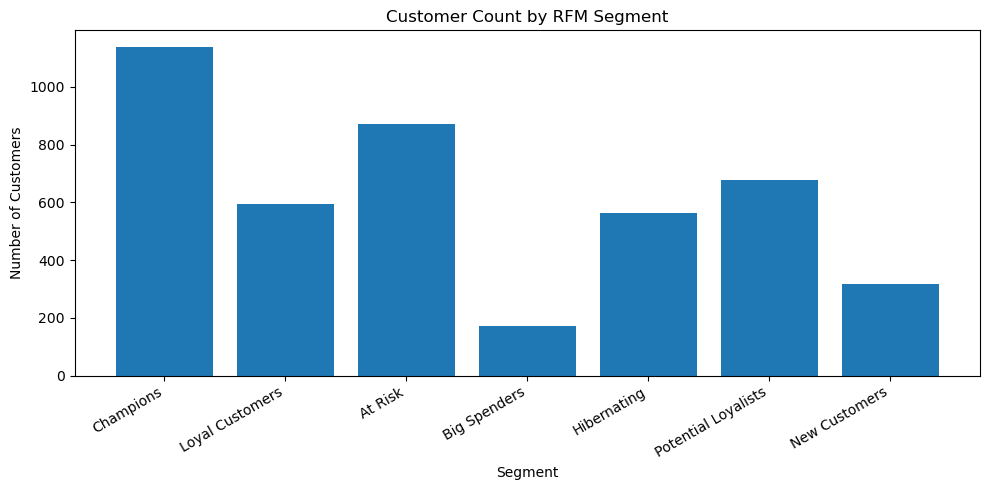

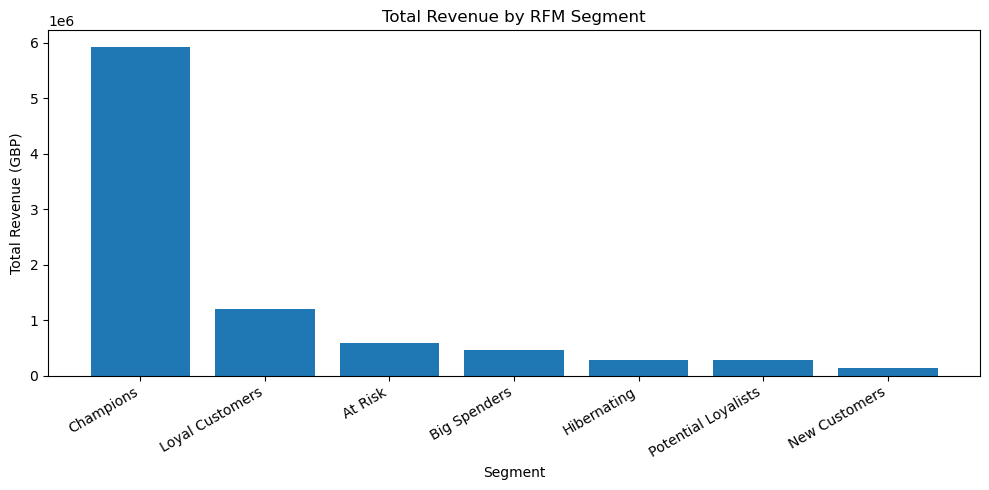

,Segment,Customers,TotalRevenue,RevenueSharePct,AvgRevenuePerCustomer,AvgFrequency,AvgRecencyDays
2,Champions,1139,5927723.911,66.518377,5204.323012,9.986831,13.311677
4,Loyal Customers,596,1209093.950,13.567934,2028.681124,5.317114,90.491611
0,At Risk,870,595746.843,6.685216,684.766486,1.671264,192.762069
1,Big Spenders,173,456258.090,5.119933,2637.330000,2.410405,36.335260
3,Hibernating,563,290956.290,3.264987,516.796252,1.000000,221.920071
6,Potential Loyalists,678,285462.250,3.203335,421.035767,1.707965,40.547198
5,New Customers,319,146166.570,1.640219,458.202414,1.241379,18.517241


In [8]:


import matplotlib.pyplot as plt

# Prepare plotting data (already sorted by revenue in segment_summary)
plot_df = segment_summary.copy()

# 1) Customers by segment
plt.figure(figsize=(10, 5))
plt.bar(plot_df["Segment"], plot_df["Customers"])
plt.xticks(rotation=30, ha="right")
plt.title("Customer Count by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 2) Revenue by segment
plt.figure(figsize=(10, 5))
plt.bar(plot_df["Segment"], plot_df["TotalRevenue"])
plt.xticks(rotation=30, ha="right")
plt.title("Total Revenue by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue (GBP)")
plt.tight_layout()
plt.show()

# Optional: show the underlying summary table again for reference
display(plot_df[["Segment","Customers","TotalRevenue","RevenueSharePct","AvgRevenuePerCustomer","AvgFrequency","AvgRecencyDays"]])

In [9]:


# 1) Create an "OrderMonth" column at the invoice level
invoice_cohort = invoice_df.copy()
invoice_cohort["OrderMonth"] = invoice_cohort["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

# 2) Find each customer's cohort month (their first purchase month)
invoice_cohort["CohortMonth"] = (
    invoice_cohort.groupby("CustomerID")["OrderMonth"].transform("min")
)

# 3) Compute the number of months between OrderMonth and CohortMonth
def month_diff(later, earlier):
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)

invoice_cohort["CohortIndex"] = month_diff(invoice_cohort["OrderMonth"], invoice_cohort["CohortMonth"])

# 4) Count unique customers per cohort month and cohort index
cohort_counts = (
    invoice_cohort
    .groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index(name="ActiveCustomers")
)

# 5) Convert to matrix form (rows = cohorts, columns = months since first purchase)
cohort_matrix = cohort_counts.pivot(index="CohortMonth", columns="CohortIndex", values="ActiveCustomers")

# 6) Retention rate = active customers in month k / customers in month 0
cohort_sizes = cohort_matrix[0]
cohort_retention = cohort_matrix.divide(cohort_sizes, axis=0)

print("Cohort retention matrix shape:", cohort_retention.shape)
display(cohort_retention.head())

Cohort retention matrix shape: (13, 13)


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


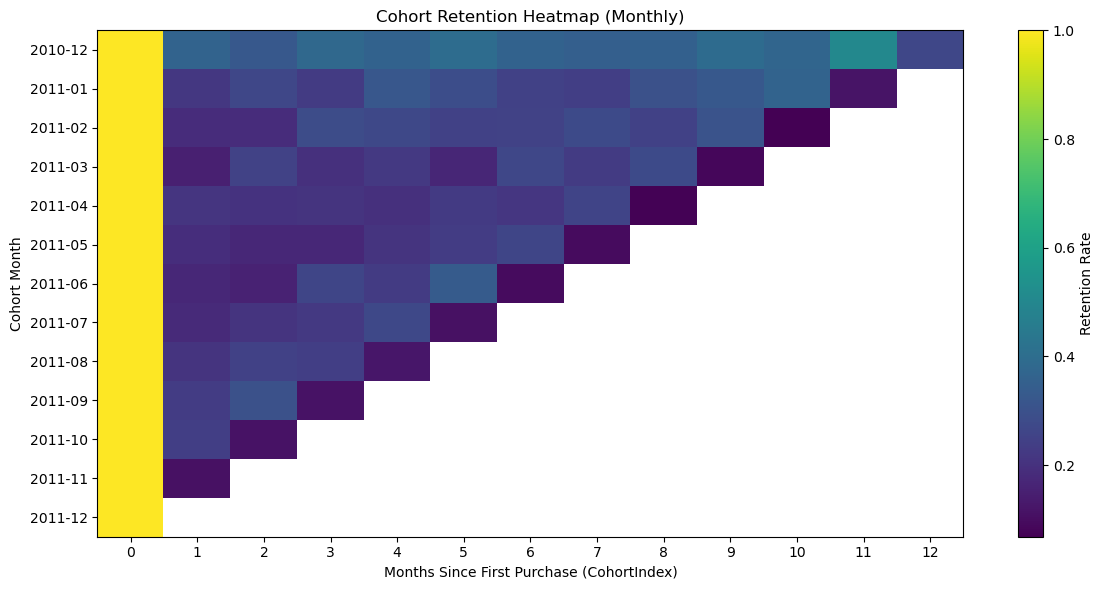

In [10]:
# ============================================================

#  retention heatmap that shows, for each cohort month,
#   what fraction of customers return in subsequent months.
#   - Missing cells (NaN) occur because later cohorts do not have enough
#     future months in the dataset window.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Convert to a numpy array for plotting
retention_values = cohort_retention.values

plt.figure(figsize=(12, 6))
im = plt.imshow(retention_values, aspect="auto")

# Axis labels
plt.title("Cohort Retention Heatmap (Monthly)")
plt.xlabel("Months Since First Purchase (CohortIndex)")
plt.ylabel("Cohort Month")

# Tick labels
plt.xticks(
    ticks=np.arange(cohort_retention.shape[1]),
    labels=cohort_retention.columns.astype(int)
)
plt.yticks(
    ticks=np.arange(cohort_retention.shape[0]),
    labels=cohort_retention.index.strftime("%Y-%m")
)

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Retention Rate")

plt.tight_layout()
plt.show()

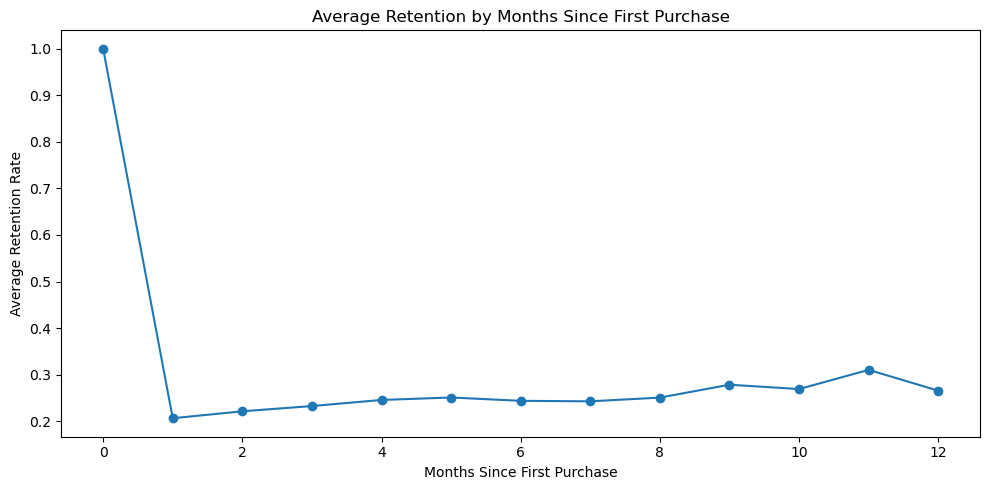

In [11]:
# ============================================================
# — Retention curve (average across cohorts)
#   Plot average retention by month since first purchase to summarize the heatmap.
# ============================================================

import matplotlib.pyplot as plt

avg_ret_by_month = cohort_retention.mean(axis=0, skipna=True)

plt.figure(figsize=(10, 5))
plt.plot(avg_ret_by_month.index.astype(int), avg_ret_by_month.values, marker="o")
plt.title("Average Retention by Months Since First Purchase")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention Rate")
plt.tight_layout()
plt.show()

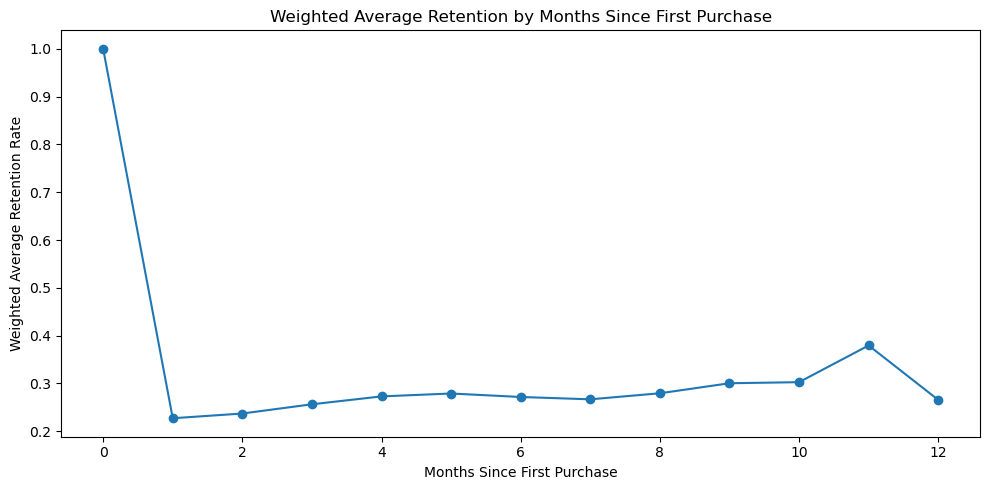

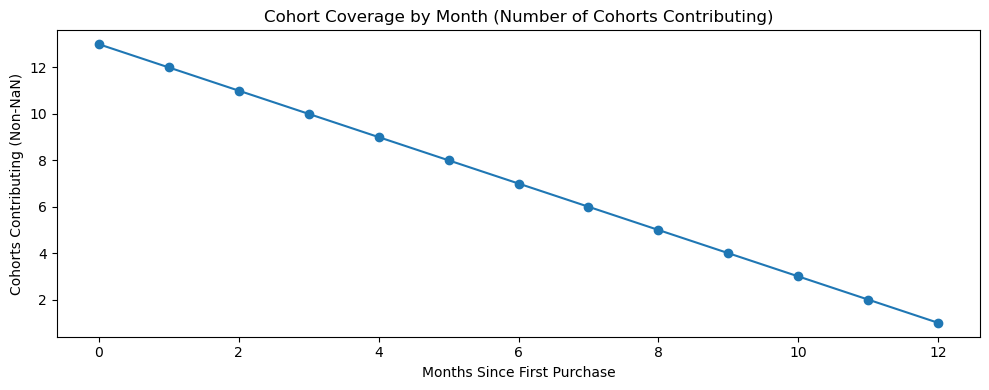

,MonthIndex,WeightedRetention,CohortsContributing
0,0,1.000000,13
1,1,0.227135,12
2,2,0.237041,11
3,3,0.256361,10
4,4,0.272837,9
5,5,0.278907,8
6,6,0.271622,7
7,7,0.266740,6
8,8,0.279376,5
9,9,0.300375,4


In [12]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure we have cohort sizes (Month 0 active customers for each cohort)
cohort_sizes = cohort_matrix[0]

# 1) Weighted average retention:
#    numerator: sum over cohorts of (retention_rate * cohort_size), ignoring NaNs
#    denominator: sum of cohort_size for cohorts that have non-NaN retention in that month
numerator = cohort_retention.mul(cohort_sizes, axis=0).sum(axis=0, skipna=True)
denominator = cohort_retention.notna().mul(cohort_sizes, axis=0).sum(axis=0)
weighted_retention = numerator / denominator

# 2) Cohort coverage (how many cohorts contribute each month)
cohorts_contributing = cohort_retention.notna().sum(axis=0)

# Plot weighted retention curve
plt.figure(figsize=(10, 5))
plt.plot(weighted_retention.index.astype(int), weighted_retention.values, marker="o")
plt.title("Weighted Average Retention by Months Since First Purchase")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Weighted Average Retention Rate")
plt.tight_layout()
plt.show()

# Plot cohort coverage curve
plt.figure(figsize=(10, 4))
plt.plot(cohorts_contributing.index.astype(int), cohorts_contributing.values, marker="o")
plt.title("Cohort Coverage by Month (Number of Cohorts Contributing)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohorts Contributing (Non-NaN)")
plt.tight_layout()
plt.show()

# Quick table preview
coverage_table = pd.DataFrame({
    "MonthIndex": weighted_retention.index.astype(int),
    "WeightedRetention": weighted_retention.values,
    "CohortsContributing": cohorts_contributing.values
})
display(coverage_table.head(10))

In [13]:

# 1) Average retention at selected months (ignoring NaNs)
months_to_report = [1, 3, 6]
avg_retention = {
    f"AvgRetention_Month{m}": float(cohort_retention[m].mean(skipna=True))
    for m in months_to_report
    if m in cohort_retention.columns
}
avg_retention_df = pd.DataFrame([avg_retention])

# 2) Overall repeat purchase rate (based on invoice counts per customer)
repeat_stats = (
    invoice_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .rename("InvoiceCount")
    .reset_index()
)

repeat_rate = (repeat_stats["InvoiceCount"] >= 2).mean()
repeat_summary_df = pd.DataFrame([{
    "TotalCustomers": int(repeat_stats["CustomerID"].nunique()),
    "RepeatCustomers_2Plus": int((repeat_stats["InvoiceCount"] >= 2).sum()),
    "RepeatPurchaseRate": float(repeat_rate)
}])

# 3) Time-to-second-purchase (days)
#    Compute the gap between the first and second invoice dates per customer.
purchase_dates = (
    invoice_df.sort_values(["CustomerID", "InvoiceDate"])
    .groupby("CustomerID")["InvoiceDate"]
    .apply(list)
)

# Keep only customers with at least 2 purchases
second_purchase_gaps = []
for cust_id, dates in purchase_dates.items():
    if len(dates) >= 2:
        gap_days = (dates[1] - dates[0]).days
        second_purchase_gaps.append(gap_days)

second_purchase_gaps = pd.Series(second_purchase_gaps, name="DaysToSecondPurchase")

gap_summary_df = pd.DataFrame([{
    "CustomersWith2PlusPurchases": int(second_purchase_gaps.shape[0]),
    "MedianDaysToSecondPurchase": float(second_purchase_gaps.median()),
    "P25Days": float(second_purchase_gaps.quantile(0.25)),
    "P75Days": float(second_purchase_gaps.quantile(0.75))
}])

print("Average Retention (selected months):")
display(avg_retention_df)

print("Repeat purchase summary:")
display(repeat_summary_df)

print("Time-to-second-purchase summary (days):")
display(gap_summary_df)

Average Retention (selected months):


,AvgRetention_Month1,AvgRetention_Month3,AvgRetention_Month6
0,0.206232,0.232444,0.243691


Repeat purchase summary:


,TotalCustomers,RepeatCustomers_2Plus,RepeatPurchaseRate
0,4338,2845,0.655832


Time-to-second-purchase summary (days):


,CustomersWith2PlusPurchases,MedianDaysToSecondPurchase,P25Days,P75Days
0,2845,50.0,19.0,112.0


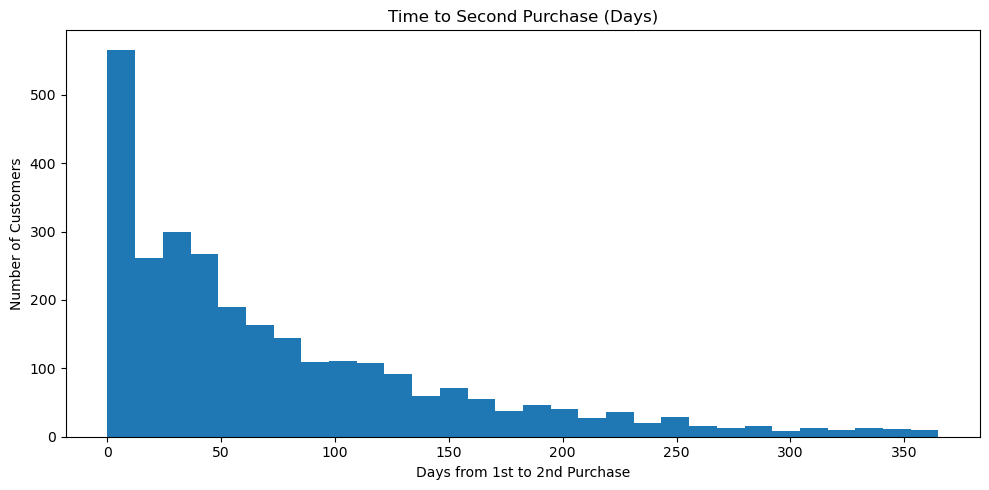

In [14]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(second_purchase_gaps, bins=30)
plt.title("Time to Second Purchase (Days)")
plt.xlabel("Days from 1st to 2nd Purchase")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [15]:

#    We set it to 60 days before the last purchase date to ensure a full 30-day label window.
last_date = invoice_df["InvoiceDate"].max()
cutoff_date = last_date - pd.Timedelta(days=60)

# 2) Split invoice data into "history" (features) and "future window" (label)
history_invoices = invoice_df.loc[invoice_df["InvoiceDate"] <= cutoff_date].copy()
future_window = invoice_df.loc[
    (invoice_df["InvoiceDate"] > cutoff_date) &
    (invoice_df["InvoiceDate"] <= cutoff_date + pd.Timedelta(days=30))
].copy()

# 3) Build customer features from history only (no leakage)
analysis_date_model = cutoff_date + pd.Timedelta(days=1)

model_features = (
    history_invoices
    .groupby("CustomerID", as_index=False)
    .agg(
        LastPurchaseDate=("InvoiceDate", "max"),
        FirstPurchaseDate=("InvoiceDate", "min"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("InvoiceValue", "sum"),
        AvgOrderValue=("InvoiceValue", "mean"),
        AvgBasketSize=("ItemsTotal", "mean"),
        AvgUniqueItems=("UniqueItems", "mean")
    )
)

model_features["RecencyDays"] = (analysis_date_model - model_features["LastPurchaseDate"]).dt.days
model_features["CustomerAgeDays"] = (model_features["LastPurchaseDate"] - model_features["FirstPurchaseDate"]).dt.days

# 4) Create churn/return label: did the customer purchase within the next 30 days?
future_buyers = set(future_window["CustomerID"].unique())
model_features["PurchasedNext30Days"] = model_features["CustomerID"].apply(lambda x: 1 if x in future_buyers else 0)

# 5) Basic sanity checks
print("Cutoff date:", cutoff_date)
print("History invoices:", history_invoices.shape[0], "| Future window invoices:", future_window.shape[0])
print("Customers in modeling data:", model_features.shape[0])
print("Positive class rate (PurchasedNext30Days=1):", model_features["PurchasedNext30Days"].mean())

# Preview the modeling dataset
display(model_features.head(10))

Cutoff date: 2011-10-10 12:50:00
History invoices: 13717 | Future window invoices: 2077
Customers in modeling data: 3731
Positive class rate (PurchasedNext30Days=1): 0.2967032967032967


,CustomerID,LastPurchaseDate,FirstPurchaseDate,Frequency,Monetary,AvgOrderValue,AvgBasketSize,AvgUniqueItems,RecencyDays,CustomerAgeDays,PurchasedNext30Days
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600000,74215.000000,1.000000,266,0,0
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,5,2790.86,558.172000,318.000000,24.800000,70,237,1
2,12348,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,449.310000,585.250000,6.750000,15,282,0
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400000,197.000000,17.000000,250,0,0
4,12352,2011-09-28 14:58:00,2011-02-16 12:33:00,7,2194.31,313.472857,58.428571,9.714286,12,224,1
5,12353,2011-05-19 17:47:00,2011-05-19 17:47:00,1,89.00,89.000000,20.000000,4.000000,144,0,0
6,12354,2011-04-21 13:11:00,2011-04-21 13:11:00,1,1079.40,1079.400000,530.000000,58.000000,172,0,0
7,12355,2011-05-09 13:49:00,2011-05-09 13:49:00,1,459.40,459.400000,240.000000,13.000000,154,0,0
8,12356,2011-04-08 12:33:00,2011-01-18 09:50:00,2,2753.08,1376.540000,793.000000,28.500000,186,80,0
9,12358,2011-07-12 10:04:00,2011-07-12 10:04:00,1,484.86,484.860000,100.000000,12.000000,91,0,0


In [16]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, classification_report

# 1) Define features and target
feature_cols = [
    "RecencyDays", "Frequency", "Monetary",
    "AvgOrderValue", "AvgBasketSize", "AvgUniqueItems",
    "CustomerAgeDays"
]
X = model_features[feature_cols].copy()
y = model_features["PurchasedNext30Days"].copy()

# 2) Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Build an interpretable pipeline: scaling + logistic regression
clf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

# 4) Train
clf.fit(X_train, y_train)

# 5) Predict probabilities and labels
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# 6) Evaluation metrics
roc_auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)

print(f"ROC-AUC:   {roc_auc:.3f}")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

# 7) Interpret model coefficients (after scaling)
coef = clf.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({"Feature": feature_cols, "Coefficient": coef}).sort_values("Coefficient", ascending=False)

print("\nTop positive drivers (increase probability of purchasing in next 30 days):")
display(coef_df.head(5))

print("\nTop negative drivers (decrease probability of purchasing in next 30 days):")
display(coef_df.tail(5))

ROC-AUC:   0.692
Accuracy:  0.663
Precision: 0.447
Recall:    0.563

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.71      0.75       656
           1       0.45      0.56      0.50       277

    accuracy                           0.66       933
   macro avg       0.62      0.63      0.62       933
weighted avg       0.69      0.66      0.67       933


Top positive drivers (increase probability of purchasing in next 30 days):


,Feature,Coefficient
1,Frequency,1.328396
5,AvgUniqueItems,0.184787
6,CustomerAgeDays,0.044856
4,AvgBasketSize,0.035701
2,Monetary,0.014608



Top negative drivers (decrease probability of purchasing in next 30 days):


,Feature,Coefficient
6,CustomerAgeDays,0.044856
4,AvgBasketSize,0.035701
2,Monetary,0.014608
3,AvgOrderValue,-0.092767
0,RecencyDays,-0.339227


Baseline purchase rate (test set): 0.297


,Decile,Customers,ActualPurchaseRate,AvgPredictedProb,Lift
9,10,94,0.680851,0.870759,2.293264
8,9,93,0.419355,0.663213,1.412484
7,8,93,0.376344,0.570458,1.267614
6,7,93,0.258065,0.511238,0.869221
5,6,93,0.279570,0.466224,0.941656
4,5,94,0.265957,0.423745,0.895806
3,4,93,0.193548,0.386451,0.651916
2,3,93,0.204301,0.336934,0.688133
1,2,93,0.129032,0.275593,0.434610
0,1,94,0.159574,0.208736,0.537484


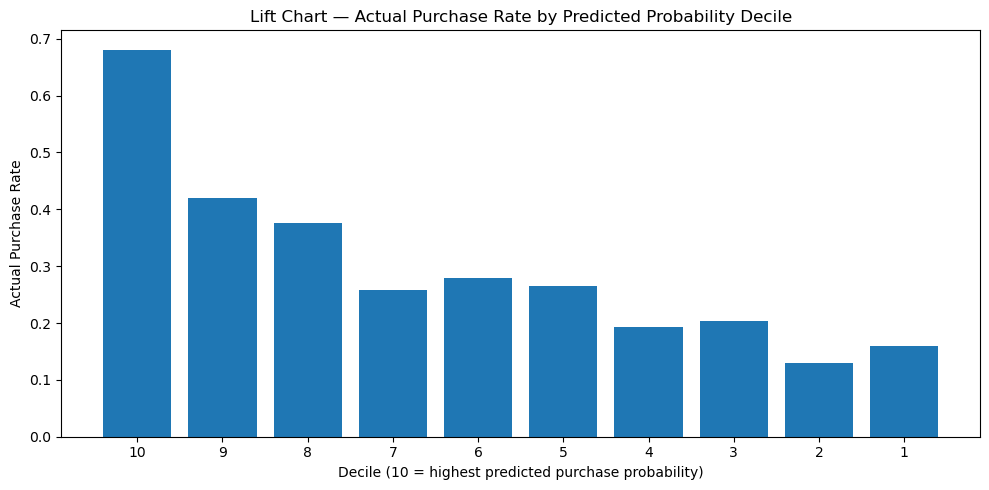

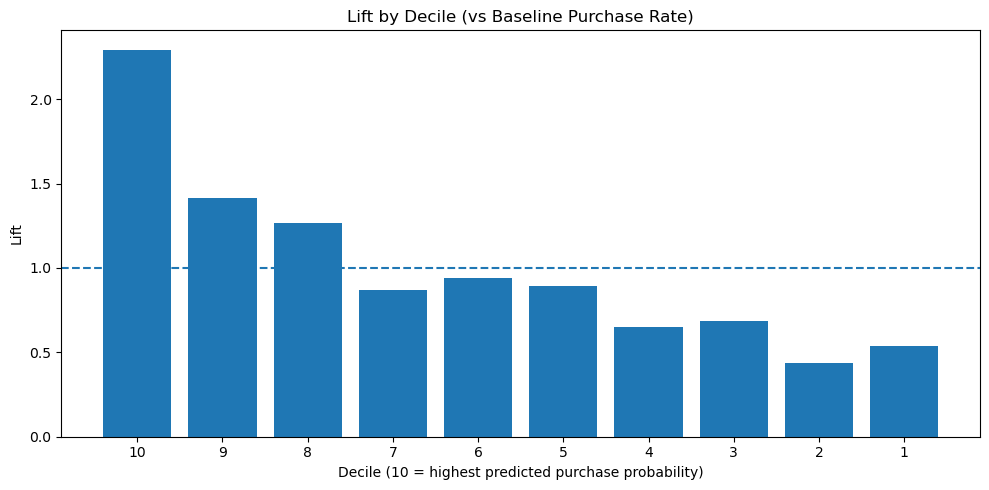

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build a test-set evaluation table
eval_df = X_test.copy()
eval_df["y_true"] = y_test.values
eval_df["y_prob"] = clf.predict_proba(X_test)[:, 1]

# Create deciles: 10 = highest predicted probability, 1 = lowest
eval_df["Decile"] = pd.qcut(eval_df["y_prob"], 10, labels=False, duplicates="drop") + 1
eval_df["Decile"] = eval_df["Decile"].astype(int)

# Summarize performance by decile
decile_summary = (
    eval_df
    .groupby("Decile", as_index=False)
    .agg(
        Customers=("y_true", "size"),
        ActualPurchaseRate=("y_true", "mean"),
        AvgPredictedProb=("y_prob", "mean")
    )
)

# Compute lift relative to baseline purchase rate
baseline_rate = eval_df["y_true"].mean()
decile_summary["Lift"] = decile_summary["ActualPurchaseRate"] / baseline_rate

# Sort so Decile 10 is shown first (highest predicted)
decile_summary = decile_summary.sort_values("Decile", ascending=False)

print("Baseline purchase rate (test set):", round(baseline_rate, 3))
display(decile_summary)

# Plot: Actual purchase rate by decile
plt.figure(figsize=(10, 5))
plt.bar(decile_summary["Decile"].astype(str), decile_summary["ActualPurchaseRate"])
plt.title("Lift Chart — Actual Purchase Rate by Predicted Probability Decile")
plt.xlabel("Decile (10 = highest predicted purchase probability)")
plt.ylabel("Actual Purchase Rate")
plt.tight_layout()
plt.show()

# Plot: Lift by decile
plt.figure(figsize=(10, 5))
plt.bar(decile_summary["Decile"].astype(str), decile_summary["Lift"])
plt.title("Lift by Decile (vs Baseline Purchase Rate)")
plt.xlabel("Decile (10 = highest predicted purchase probability)")
plt.ylabel("Lift")
plt.axhline(1.0, linestyle="--")  # baseline
plt.tight_layout()
plt.show()

In [19]:


# 1) Score customers in the modeling table
model_features_scored = model_features.copy()
model_features_scored["ProbPurchaseNext30Days"] = clf.predict_proba(model_features_scored[feature_cols])[:, 1]

# 2) Define churn risk as the inverse of purchase probability
model_features_scored["ChurnRiskScore"] = 1 - model_features_scored["ProbPurchaseNext30Days"]

# 3) Merge churn risk back to the RFM segmentation table (rfm_df)
#    Note: rfm_df is built from the full window; model_features is built from history-only.
#    For customers not present in model_features (e.g., first purchase after cutoff),
#    churn score will be missing (that is expected).
scored_customers = (
    rfm_df.merge(
        model_features_scored[["CustomerID", "ProbPurchaseNext30Days", "ChurnRiskScore"]],
        on="CustomerID",
        how="left"
    )
)

# 4) Create a prioritization view:
#    - High churn risk (top 20%)
#    - High value (top 20% HistoricalCLV)
risk_threshold = scored_customers["ChurnRiskScore"].quantile(0.80)
value_threshold = scored_customers["HistoricalCLV"].quantile(0.80)

top_priority = scored_customers.loc[
    (scored_customers["ChurnRiskScore"] >= risk_threshold) &
    (scored_customers["HistoricalCLV"] >= value_threshold)
].copy()

top_priority = top_priority.sort_values(["HistoricalCLV", "ChurnRiskScore"], ascending=[False, False])

print("Scored customers shape:", scored_customers.shape)
print("Customers with churn scores available:", scored_customers["ChurnRiskScore"].notna().sum())

print("\nPriority list size (High value + High churn risk):", top_priority.shape[0])
print("Risk threshold (80th percentile):", risk_threshold)
print("Value threshold (80th percentile):", value_threshold)

# Show the top 15 priority customers (what you'd act on)
display(
    top_priority[[
        "CustomerID", "Segment", "HistoricalCLV", "Frequency", "RecencyDays",
        "ProbPurchaseNext30Days", "ChurnRiskScore"
    ]].head(15)
)

Scored customers shape: (4338, 18)
Customers with churn scores available: 3731

Priority list size (High value + High churn risk): 14
Risk threshold (80th percentile): 0.7067783039788178
Value threshold (80th percentile): 2058.426000000001


,CustomerID,Segment,HistoricalCLV,Frequency,RecencyDays,ProbPurchaseNext30Days,ChurnRiskScore
3008,16446,Big Spenders,168472.50,2,1,0.275802,0.724198
0,12346,Hibernating,77183.60,1,326,0.000412,0.999588
2502,15749,At Risk,44534.30,3,235,0.064280,0.935720
2011,15098,At Risk,39916.50,3,182,0.051856,0.948144
1662,14607,Champions,16569.50,14,16,0.227514,0.772486
196,12590,At Risk,9864.26,2,211,0.242763,0.757237
332,12755,At Risk,3811.95,2,281,0.217301,0.782699
987,13680,Champions,3722.42,4,1,0.252774,0.747226
3891,17672,Big Spenders,3178.17,2,50,0.247779,0.752221
597,13135,Hibernating,3096.00,1,197,0.258545,0.741455


In [20]:

# 1) Restrict returns table to customers we can identify
returns_known = df_returns.loc[df_returns["CustomerID"].notna()].copy()

# 2) Aggregate return behavior per customer
returns_by_customer = (
    returns_known
    .groupby("CustomerID", as_index=False)
    .agg(
        ReturnRows=("InvoiceNo", "size"),
        ReturnInvoices=("InvoiceNo", "nunique"),
        ReturnRevenue=("Revenue", "sum")  # will often be negative
    )
)

# 3) Aggregate total (sales) line-item rows per customer for a row-based return rate
sales_rows_by_customer = (
    df_sales
    .groupby("CustomerID", as_index=False)
    .agg(SalesRows=("InvoiceNo", "size"))
)

# 4) Merge and compute return rate
returns_metrics = sales_rows_by_customer.merge(returns_by_customer, on="CustomerID", how="left")
returns_metrics[["ReturnRows", "ReturnInvoices", "ReturnRevenue"]] = returns_metrics[
    ["ReturnRows", "ReturnInvoices", "ReturnRevenue"]
].fillna(0)

returns_metrics["TotalRows"] = returns_metrics["SalesRows"] + returns_metrics["ReturnRows"]
returns_metrics["ReturnRateRows"] = np.where(
    returns_metrics["TotalRows"] > 0,
    returns_metrics["ReturnRows"] / returns_metrics["TotalRows"],
    0
)

# 5) Add these metrics into the main scored_customers table
scored_customers = scored_customers.merge(
    returns_metrics[["CustomerID", "ReturnRows", "ReturnInvoices", "ReturnRevenue", "ReturnRateRows"]],
    on="CustomerID",
    how="left"
)

# Customers with no recorded returns get zeros
scored_customers[["ReturnRows", "ReturnInvoices", "ReturnRevenue", "ReturnRateRows"]] = scored_customers[
    ["ReturnRows", "ReturnInvoices", "ReturnRevenue", "ReturnRateRows"]
].fillna(0)

# 6) Quick summary for reporting
print("Customers with any returns/cancellations:", (scored_customers["ReturnRows"] > 0).sum())
print("Median return rate (row-based):", scored_customers["ReturnRateRows"].median())
print("95th percentile return rate:", scored_customers["ReturnRateRows"].quantile(0.95))

# Preview a few customers with high return rates
display(
    scored_customers.sort_values("ReturnRateRows", ascending=False)[
        ["CustomerID", "Segment", "HistoricalCLV", "ReturnRows", "ReturnInvoices", "ReturnRevenue", "ReturnRateRows"]
    ].head(10)
)

Customers with any returns/cancellations: 1563
Median return rate (row-based): 0.0
95th percentile return rate: 0.125


,CustomerID,Segment,HistoricalCLV,ReturnRows,ReturnInvoices,ReturnRevenue,ReturnRateRows
2558,15823,At Risk,15.00,16.0,1.0,-855.76,0.941176
3219,16742,Potential Loyalists,464.90,3.0,1.0,-464.90,0.750000
4191,18087,At Risk,4055.72,5.0,2.0,-285.60,0.714286
3798,17548,At Risk,103.30,12.0,2.0,-244.78,0.705882
2540,15802,At Risk,451.42,2.0,2.0,-902.84,0.666667
983,13672,At Risk,186.39,10.0,4.0,-257.85,0.625000
2107,15221,Hibernating,403.25,6.0,1.0,-289.15,0.545455
2013,15100,At Risk,876.00,3.0,3.0,-240.90,0.500000
2732,16073,At Risk,122.40,1.0,1.0,-28.05,0.500000
4178,18072,At Risk,247.44,18.0,1.0,-247.44,0.500000


Returns / cancellations behavior by segment:


,Segment,Customers,AvgReturnRate,MedianReturnRate,P90ReturnRate,AvgReturnInvoices,TotalReturnRevenue,PctCustomersWithReturns
0,At Risk,870,0.031789,0.000000,0.090909,0.321839,-82387.49,22.643678
1,Big Spenders,173,0.027896,0.000000,0.064911,0.612717,-185955.60,42.196532
4,Loyal Customers,596,0.027300,0.005323,0.080313,1.013423,-67038.22,51.342282
2,Champions,1139,0.025321,0.009740,0.070838,2.060579,-176473.42,63.652327
3,Hibernating,563,0.022022,0.000000,0.066667,0.175844,-82232.82,16.341030
5,New Customers,319,0.018289,0.000000,0.051111,0.181818,-1932.81,15.047022
6,Potential Loyalists,678,0.017697,0.000000,0.051724,0.231563,-4910.49,17.994100


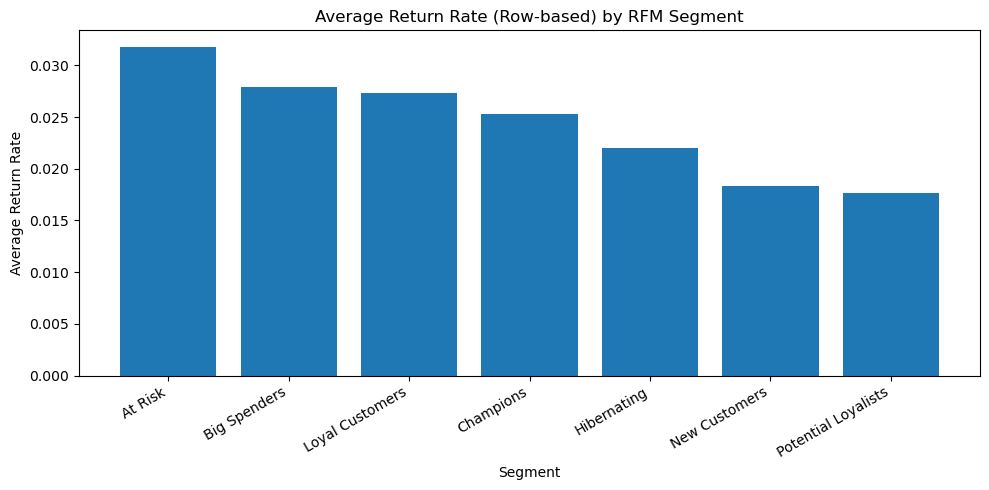

In [21]:

import matplotlib.pyplot as plt

returns_segment_summary = (
    scored_customers
    .groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        AvgReturnRate=("ReturnRateRows", "mean"),
        MedianReturnRate=("ReturnRateRows", "median"),
        P90ReturnRate=("ReturnRateRows", lambda x: x.quantile(0.90)),
        AvgReturnInvoices=("ReturnInvoices", "mean"),
        TotalReturnRevenue=("ReturnRevenue", "sum")
    )
)

# Add a helpful interpretation column: % customers with any returns
customers_with_returns = (
    scored_customers.assign(HasReturns=scored_customers["ReturnRows"] > 0)
    .groupby("Segment")["HasReturns"]
    .mean()
    .rename("PctCustomersWithReturns")
    .reset_index()
)
customers_with_returns["PctCustomersWithReturns"] *= 100

returns_segment_summary = returns_segment_summary.merge(customers_with_returns, on="Segment", how="left")

# Sort by average return rate for visibility
returns_segment_summary = returns_segment_summary.sort_values("AvgReturnRate", ascending=False)

print("Returns / cancellations behavior by segment:")
display(returns_segment_summary)

# Plot: Average return rate by segment
plt.figure(figsize=(10, 5))
plt.bar(returns_segment_summary["Segment"], returns_segment_summary["AvgReturnRate"])
plt.xticks(rotation=30, ha="right")
plt.title("Average Return Rate (Row-based) by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Average Return Rate")
plt.tight_layout()
plt.show()

In [22]:


from pathlib import Path

# Create a writable outputs directory relative to the notebook location
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Customer master table (main deliverable)
customer_master_path = OUTPUT_DIR / "customer_master_table.csv"
scored_customers.to_csv(customer_master_path, index=False)

# 2) Cohort retention matrix (matrix form)
cohort_matrix_path = OUTPUT_DIR / "cohort_retention_matrix.csv"
cohort_retention.to_csv(cohort_matrix_path, index=True)

# 3) Cohort retention tidy (long) form (best for BI / charts)
cohort_tidy = (
    cohort_retention
    .reset_index()
    .melt(id_vars="CohortMonth", var_name="CohortIndex", value_name="RetentionRate")
    .dropna(subset=["RetentionRate"])
)
cohort_tidy_path = OUTPUT_DIR / "cohort_retention_tidy.csv"
cohort_tidy.to_csv(cohort_tidy_path, index=False)

print("Saved files to:", OUTPUT_DIR.resolve())
print("1)", customer_master_path)
print("2)", cohort_matrix_path)
print("3)", cohort_tidy_path)

# Small preview to confirm
print("\nCustomer master table preview:")
display(scored_customers.head())

print("\nCohort retention tidy preview:")
display(cohort_tidy.head())

Saved files to: /Users/ankita/outputs
1) outputs/customer_master_table.csv
2) outputs/cohort_retention_matrix.csv
3) outputs/cohort_retention_tidy.csv

Customer master table preview:


,CustomerID,LastPurchaseDate,FirstPurchaseDate,Frequency,Monetary,AvgOrderValue,AvgBasketSize,AvgUniqueItems,RecencyDays,CustomerAgeDays,...,F_Score,M_Score,RFM_Score,Segment,ProbPurchaseNext30Days,ChurnRiskScore,ReturnRows,ReturnInvoices,ReturnRevenue,ReturnRateRows
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600000,74215.000000,1.00,326,0,...,1,5,115,Hibernating,0.000412,0.999588,1.0,1.0,-77183.6,0.5
1,12347,2011-12-07 15:52:00,2010-12-07 14:57:00,7,4310.00,615.714286,351.142857,26.00,2,365,...,5,5,555,Champions,0.597326,0.402674,0.0,0.0,0.0,0.0
2,12348,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,449.310000,585.250000,6.75,75,282,...,4,4,244,Loyal Customers,0.570529,0.429471,0.0,0.0,0.0,0.0
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,1757.550000,631.000000,73.00,19,0,...,1,4,414,New Customers,NaN,NaN,0.0,0.0,0.0,0.0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400000,197.000000,17.00,310,0,...,1,2,112,Hibernating,0.223161,0.776839,0.0,0.0,0.0,0.0



Cohort retention tidy preview:


,CohortMonth,CohortIndex,RetentionRate
0,2010-12-01,0,1.0
1,2011-01-01,0,1.0
2,2011-02-01,0,1.0
3,2011-03-01,0,1.0
4,2011-04-01,0,1.0


In [23]:


# 1) Net revenue at customer level (sales revenue + return/cancellation revenue)
scored_customers["NetRevenue"] = scored_customers["Monetary"] + scored_customers["ReturnRevenue"]

# 2) Flag customers whose net value is non-positive (often fully returned / data anomaly)
scored_customers["FullyReturnedCustomer"] = scored_customers["NetRevenue"] <= 0

# 3) Summary
n_customers = scored_customers["CustomerID"].nunique()
n_fully_returned = int(scored_customers["FullyReturnedCustomer"].sum())
pct_fully_returned = 100 * n_fully_returned / n_customers

print("Customers total:", n_customers)
print("Fully returned customers (NetRevenue <= 0):", n_fully_returned)
print(f"Percent fully returned: {pct_fully_returned:.2f}%")

# 4) Show top cases (large sales value but net is <= 0)
display(
    scored_customers.loc[scored_customers["FullyReturnedCustomer"]]
    .sort_values("Monetary", ascending=False)[
        ["CustomerID", "Segment", "Monetary", "ReturnRevenue", "NetRevenue",
         "ReturnInvoices", "ReturnRateRows", "ChurnRiskScore"]
    ]
    .head(15)
)

Customers total: 4338
Fully returned customers (NetRevenue <= 0): 19
Percent fully returned: 0.44%


,CustomerID,Segment,Monetary,ReturnRevenue,NetRevenue,ReturnInvoices,ReturnRateRows,ChurnRiskScore
0,12346,Hibernating,77183.60,-77183.60,0.00,1.0,0.500000,0.999588
210,12607,Big Spenders,1579.51,-1579.51,0.00,1.0,0.500000,NaN
1629,14557,Hibernating,788.38,-788.38,0.00,1.0,0.500000,0.612770
3078,16546,At Risk,787.15,-883.08,-95.93,1.0,0.193548,0.728457
3219,16742,Potential Loyalists,464.90,-464.90,0.00,1.0,0.750000,NaN
2540,15802,At Risk,451.42,-902.84,-451.42,2.0,0.666667,0.694530
3839,17603,At Risk,394.72,-1560.02,-1165.30,4.0,0.266667,0.612238
168,12558,New Customers,269.96,-269.96,0.00,1.0,0.500000,NaN
4178,18072,At Risk,247.44,-247.44,0.00,1.0,0.500000,0.677691
983,13672,At Risk,186.39,-257.85,-71.46,4.0,0.625000,0.752666


In [24]:

# 1) Final value metric for reporting
scored_customers["ValueForReporting"] = scored_customers["NetRevenue"]

# 2) Segment-level summary using NetRevenue (more realistic than sales-only Monetary)
segment_value_summary = (
    scored_customers
    .groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalValue=("ValueForReporting", "sum"),
        AvgValuePerCustomer=("ValueForReporting", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgRecencyDays=("RecencyDays", "mean"),
        PctFullyReturned=("FullyReturnedCustomer", "mean")
    )
)

segment_value_summary["ValueSharePct"] = 100 * segment_value_summary["TotalValue"] / segment_value_summary["TotalValue"].sum()
segment_value_summary["PctFullyReturned"] = 100 * segment_value_summary["PctFullyReturned"]

segment_value_summary = segment_value_summary.sort_values("TotalValue", ascending=False)

print("Segment value contribution (using NetRevenue as ValueForReporting):")
display(segment_value_summary)

# 3) Show the total difference between sales-only and net value at dataset level
total_sales_value = scored_customers["Monetary"].sum()
total_net_value = scored_customers["NetRevenue"].sum()

print(f"\nTotal Monetary (sales-only): {total_sales_value:,.2f}")
print(f"Total NetRevenue (sales + returns): {total_net_value:,.2f}")
print(f"Difference (Net - Sales): {(total_net_value - total_sales_value):,.2f}")

Segment value contribution (using NetRevenue as ValueForReporting):


,Segment,Customers,TotalValue,AvgValuePerCustomer,AvgFrequency,AvgRecencyDays,PctFullyReturned,ValueSharePct
2,Champions,1139,5751250.491,5049.385857,9.986831,13.311677,0.000000,69.204818
4,Loyal Customers,596,1142055.730,1916.200889,5.317114,90.491611,0.000000,13.742361
0,At Risk,870,513359.353,590.068222,1.671264,192.762069,1.034483,6.177255
6,Potential Loyalists,678,280551.760,413.793156,1.707965,40.547198,0.589971,3.375880
1,Big Spenders,173,270302.490,1562.442139,2.410405,36.335260,0.578035,3.252551
3,Hibernating,563,208723.470,370.734405,1.000000,221.920071,0.532860,2.511570
5,New Customers,319,144233.760,452.143448,1.241379,18.517241,0.626959,1.735565



Total Monetary (sales-only): 8,911,407.90
Total NetRevenue (sales + returns): 8,310,477.05
Difference (Net - Sales): -600,930.85


In [25]:

# 1) Define thresholds using NetRevenue-based value
risk_threshold = scored_customers["ChurnRiskScore"].quantile(0.80)
value_threshold_net = scored_customers["NetRevenue"].quantile(0.80)

priority_net = scored_customers.loc[
    (scored_customers["ChurnRiskScore"].notna()) &
    (scored_customers["ChurnRiskScore"] >= risk_threshold) &
    (scored_customers["NetRevenue"] >= value_threshold_net) &
    (~scored_customers["FullyReturnedCustomer"])
].copy()

priority_net = priority_net.sort_values(["NetRevenue", "ChurnRiskScore"], ascending=[False, False])

print("Risk threshold (80th percentile):", risk_threshold)
print("NetRevenue threshold (80th percentile):", value_threshold_net)
print("Priority list size (NetRevenue-based):", priority_net.shape[0])

# Show the top 15 customers to target
display(
    priority_net[[
        "CustomerID", "Segment", "NetRevenue", "Frequency", "RecencyDays",
        "ProbPurchaseNext30Days", "ChurnRiskScore",
        "ReturnRateRows", "ReturnInvoices"
    ]].head(15)
)

Risk threshold (80th percentile): 0.7067783039788178
NetRevenue threshold (80th percentile): 2016.2140000000024
Priority list size (NetRevenue-based): 13


,CustomerID,Segment,NetRevenue,Frequency,RecencyDays,ProbPurchaseNext30Days,ChurnRiskScore,ReturnRateRows,ReturnInvoices
2502,15749,At Risk,21535.90,3,235,0.064280,0.935720,0.333333,1.0
1662,14607,Champions,11341.10,14,16,0.227514,0.772486,0.245614,3.0
196,12590,At Risk,9861.38,2,211,0.242763,0.757237,0.028571,1.0
3891,17672,Big Spenders,3106.62,2,50,0.247779,0.752221,0.043478,2.0
597,13135,Hibernating,3096.00,1,197,0.258545,0.741455,0.000000,0.0
184,12578,New Customers,2753.36,2,21,0.275639,0.724361,0.050000,2.0
1533,14439,Hibernating,2661.24,1,320,0.177714,0.822286,0.000000,0.0
4279,18210,Champions,2621.38,6,2,0.234176,0.765824,0.000000,0.0
2304,15485,Big Spenders,2575.00,3,30,0.243835,0.756165,0.000000,0.0
332,12755,At Risk,2203.20,2,281,0.217301,0.782699,0.333333,2.0


In [26]:


# 1) Segment snapshot (top-level)
segment_snapshot = segment_value_summary[["Segment", "Customers", "ValueSharePct"]].copy()
segment_snapshot["ValueSharePct"] = segment_snapshot["ValueSharePct"].round(2)

# 2) Retention KPIs (from earlier)
ret_kpis = {
    "AvgRetention_Month1": float(avg_retention_df["AvgRetention_Month1"].iloc[0]),
    "AvgRetention_Month3": float(avg_retention_df["AvgRetention_Month3"].iloc[0]),
    "AvgRetention_Month6": float(avg_retention_df["AvgRetention_Month6"].iloc[0]),
    "RepeatPurchaseRate": float(repeat_summary_df["RepeatPurchaseRate"].iloc[0]),
    "MedianDaysToSecondPurchase": float(gap_summary_df["MedianDaysToSecondPurchase"].iloc[0]),
}

# 3) Model performance (from the last printed metrics; recompute safely here)
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score

y_prob_test = clf.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= 0.5).astype(int)

model_kpis = {
    "Model_ROC_AUC": float(roc_auc_score(y_test, y_prob_test)),
    "Model_Accuracy": float(accuracy_score(y_test, y_pred_test)),
    "Model_Precision": float(precision_score(y_test, y_pred_test, zero_division=0)),
    "Model_Recall": float(recall_score(y_test, y_pred_test, zero_division=0)),
}

# 4) Targeting KPI
targeting_kpis = {
    "HighValueHighRisk_Customers": int(priority_net.shape[0]),
    "RiskThreshold_P80": float(risk_threshold),
    "NetRevenueThreshold_P80": float(value_threshold_net),
}

# 5) Build one compact summary table
summary_rows = [
    {"Metric": "AvgRetention_Month1", "Value": round(ret_kpis["AvgRetention_Month1"], 3)},
    {"Metric": "AvgRetention_Month3", "Value": round(ret_kpis["AvgRetention_Month3"], 3)},
    {"Metric": "AvgRetention_Month6", "Value": round(ret_kpis["AvgRetention_Month6"], 3)},
    {"Metric": "RepeatPurchaseRate", "Value": round(ret_kpis["RepeatPurchaseRate"], 3)},
    {"Metric": "MedianDaysToSecondPurchase", "Value": round(ret_kpis["MedianDaysToSecondPurchase"], 1)},
    {"Metric": "Model_ROC_AUC", "Value": round(model_kpis["Model_ROC_AUC"], 3)},
    {"Metric": "Model_Precision", "Value": round(model_kpis["Model_Precision"], 3)},
    {"Metric": "Model_Recall", "Value": round(model_kpis["Model_Recall"], 3)},
    {"Metric": "HighValueHighRisk_Customers", "Value": targeting_kpis["HighValueHighRisk_Customers"]},
]

insights_summary_df = pd.DataFrame(summary_rows)

print("Segment snapshot (NetRevenue share):")
display(segment_snapshot)

print("\nKey project metrics (copy into README / LinkedIn post):")
display(insights_summary_df)

Segment snapshot (NetRevenue share):


,Segment,Customers,ValueSharePct
2,Champions,1139,69.20
4,Loyal Customers,596,13.74
0,At Risk,870,6.18
6,Potential Loyalists,678,3.38
1,Big Spenders,173,3.25
3,Hibernating,563,2.51
5,New Customers,319,1.74



Key project metrics (copy into README / LinkedIn post):


,Metric,Value
0,AvgRetention_Month1,0.206
1,AvgRetention_Month3,0.232
2,AvgRetention_Month6,0.244
3,RepeatPurchaseRate,0.656
4,MedianDaysToSecondPurchase,50.000
5,Model_ROC_AUC,0.692
6,Model_Precision,0.447
7,Model_Recall,0.563
8,HighValueHighRisk_Customers,13.000


In [27]:

# Pull key numbers
champ_share = float(segment_snapshot.loc[segment_snapshot["Segment"] == "Champions", "ValueSharePct"].iloc[0])
loyal_share = float(segment_snapshot.loc[segment_snapshot["Segment"] == "Loyal Customers", "ValueSharePct"].iloc[0])
month1 = float(insights_summary_df.loc[insights_summary_df["Metric"] == "AvgRetention_Month1", "Value"].iloc[0])
month6 = float(insights_summary_df.loc[insights_summary_df["Metric"] == "AvgRetention_Month6", "Value"].iloc[0])
repeat_rate = float(insights_summary_df.loc[insights_summary_df["Metric"] == "RepeatPurchaseRate", "Value"].iloc[0])
median_second = float(insights_summary_df.loc[insights_summary_df["Metric"] == "MedianDaysToSecondPurchase", "Value"].iloc[0])
auc = float(insights_summary_df.loc[insights_summary_df["Metric"] == "Model_ROC_AUC", "Value"].iloc[0])
priority_n = int(insights_summary_df.loc[insights_summary_df["Metric"] == "HighValueHighRisk_Customers", "Value"].iloc[0])

print("Conclusion-ready insights (paste into your report):\n")

print(f"• Revenue concentration: 'Champions' represent a large share of customer value (NetRevenue share = {champ_share:.2f}%).")
print(f"• The next most important segment is 'Loyal Customers' (NetRevenue share = {loyal_share:.2f}%), suggesting strong repeat-purchase value outside the top tier.")
print(f"• Retention is front-loaded: average Month 1 retention is {month1:.3f}, while Month 6 retention averages {month6:.3f} across cohorts.")
print(f"• Repeat purchasing is common: {repeat_rate:.3f} of customers make 2+ purchases, and the median time to a second purchase is {median_second:.0f} days.")
print(f"• Churn / re-purchase model: a simple logistic regression achieves ROC-AUC = {auc:.3f}, providing a practical risk scoring baseline.")
print(f"• Actionable targeting: {priority_n} customers are simultaneously high-value (top 20% NetRevenue) and high-risk (top 20% churn risk), making them ideal win-back targets.")
print("• Data integrity improvement: using NetRevenue (sales + returns/cancellations) prevents overstating value for fully-returned customers (0.44% of the customer base).")

Conclusion-ready insights (paste into your report):

• Revenue concentration: 'Champions' represent a large share of customer value (NetRevenue share = 69.20%).
• The next most important segment is 'Loyal Customers' (NetRevenue share = 13.74%), suggesting strong repeat-purchase value outside the top tier.
• Retention is front-loaded: average Month 1 retention is 0.206, while Month 6 retention averages 0.244 across cohorts.
• Repeat purchasing is common: 0.656 of customers make 2+ purchases, and the median time to a second purchase is 50 days.
• Churn / re-purchase model: a simple logistic regression achieves ROC-AUC = 0.692, providing a practical risk scoring baseline.
• Actionable targeting: 13 customers are simultaneously high-value (top 20% NetRevenue) and high-risk (top 20% churn risk), making them ideal win-back targets.
• Data integrity improvement: using NetRevenue (sales + returns/cancellations) prevents overstating value for fully-returned customers (0.44% of the customer base

Conclusion 

This project analyzed UK-based online retail transactions to understand customer value and behavior through segmentation, retention, and short-horizon re-purchase risk. After cleaning the data to separate genuine purchases from cancellations/return-like records (InvoiceNo starting with “C”, negative quantities, and non-positive prices), I constructed invoice-level and customer-level behavioral features. Using an RFM framework, I found strong revenue concentration: Champions account for ~69.20% of total customer value (NetRevenue), with Loyal Customers contributing ~13.74%, indicating that a relatively small share of customers drives the majority of observed value. Cohort analysis showed that repeat purchasing is meaningful in this setting: ~65.6% of customers place at least two orders, and the median time to a second purchase is ~50 days, which is operationally useful for designing follow-up and win-back timing. To quantify short-horizon risk, I trained an interpretable logistic regression model to predict whether a customer will purchase again in the next 30 days, achieving ROC-AUC ≈ 0.692 as a practical baseline for ranking customers by risk. Combining risk scores with value (using NetRevenue to avoid overstating customers whose purchases were fully returned), I identified 13 high-value, high-risk customers as immediate win-back targets. Retention rates should be interpreted primarily via the cohort heatmap, since later-month averages are based on fewer available cohorts within the one-year observation window.